<a href="https://colab.research.google.com/github/avni-arora/Competitive-Programming/blob/main/Decoding_Customer_Value_A_SQL_Driven_Retention_Strategy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from google.colab import drive

df = pd.read_csv('/content/drive/MyDrive/Dataset.csv')
df.shape
df.info()
df.describe()
df.head()
df.duplicated()
df.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

np.int64(0)

In [3]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [4]:
cat_col = [col for col in df.columns if df[col].dtype == 'object']
num_col = [col for col in df.columns if df[col].dtype != 'object']
print(cat_col)
print(num_col)

['Gender', 'Item Purchased', 'Category', 'Location', 'Size', 'Color', 'Season', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Payment Method', 'Frequency of Purchases']
['Customer ID', 'Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']


In [5]:
df = df.drop(columns=['Item Purchased','Color','Size'], axis=1)
df.describe(include='all')

,Customer ID,Age,Gender,Category,Purchase Amount (USD),Location,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900.000000,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,4,NaN,50,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Clothing,NaN,Montana,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,1737,NaN,96,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,59.764359,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,23.685392,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,20.000000,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,39.000000,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,60.000000,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,81.000000,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


In [6]:
df['Review Rating'] = df['Review Rating'].fillna(df['Review Rating'].mean().round(2))
df.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Category,0
Purchase Amount (USD),0
Location,0
Season,0
Review Rating,0
Subscription Status,0
Shipping Type,0


<Axes: xlabel='Purchase Amount (USD)'>

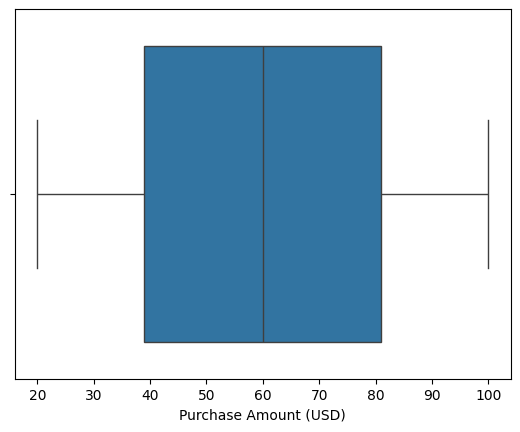

In [7]:
sns.boxplot(x=df['Purchase Amount (USD)'])


<Axes: xlabel='Previous Purchases'>

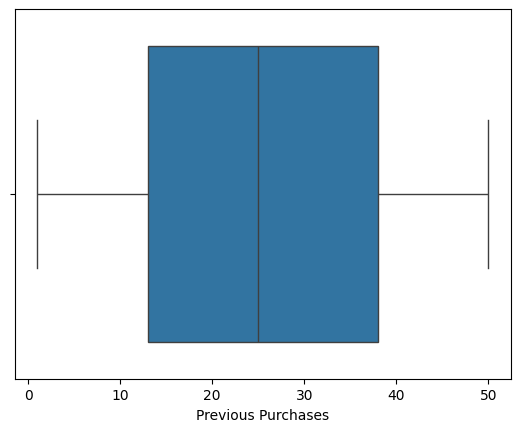

In [8]:
sns.boxplot(x=df['Previous Purchases'])

In [9]:
colx = ["Gender", "Category", "Location","Season", "Shipping Type", "Payment Method","Frequency of Purchases"]

for col in colx:
    unique_categories = pd.unique(df[col])

    print(f"{col}: {unique_categories}\n")

Gender: ['Male' 'Female']

Category: ['Clothing' 'Footwear' 'Outerwear' 'Accessories']

Location: ['Kentucky' 'Maine' 'Massachusetts' 'Rhode Island' 'Oregon' 'Wyoming'
 'Montana' 'Louisiana' 'West Virginia' 'Missouri' 'Arkansas' 'Hawaii'
 'Delaware' 'New Hampshire' 'New York' 'Alabama' 'Mississippi'
 'North Carolina' 'California' 'Oklahoma' 'Florida' 'Texas' 'Nevada'
 'Kansas' 'Colorado' 'North Dakota' 'Illinois' 'Indiana' 'Arizona'
 'Alaska' 'Tennessee' 'Ohio' 'New Jersey' 'Maryland' 'Vermont'
 'New Mexico' 'South Carolina' 'Idaho' 'Pennsylvania' 'Connecticut' 'Utah'
 'Virginia' 'Georgia' 'Nebraska' 'Iowa' 'South Dakota' 'Minnesota'
 'Washington' 'Wisconsin' 'Michigan']

Season: ['Winter' 'Spring' 'Summer' 'Fall']

Shipping Type: ['Express' 'Free Shipping' 'Next Day Air' 'Standard' '2-Day Shipping'
 'Store Pickup']

Payment Method: ['Venmo' 'Cash' 'Credit Card' 'PayPal' 'Bank Transfer' 'Debit Card']

Frequency of Purchases: ['Fortnightly' 'Weekly' 'Annually' 'Quarterly' 'Bi-Weekly' 'M

In [10]:
df['Subscription Status'] = df['Subscription Status'].map({
    'Yes': 1,
    'No': 0
})

freq = {
   'Fortnightly':3,
   'Weekly':2,
   'Annually':7,
   'Quarterly':6,
   'Bi-Weekly':1,
   'Monthly':4,
   'Every 3 Months':5
}

df['Frequency of Purchases'] = df['Frequency of Purchases'].map(freq)

df['Discount Applied'] = df['Discount Applied'].map({
    'Yes': 1,
    'No': 0
})

df['Promo Code Used'] = df['Promo Code Used'].map({
    'Yes': 1,
    'No': 0
})

In [11]:
df.head(20)

,Customer ID,Age,Gender,Category,Purchase Amount (USD),Location,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Clothing,53,Kentucky,Winter,3.1,1,Express,1,1,14,Venmo,3
1,2,19,Male,Clothing,64,Maine,Winter,3.1,1,Express,1,1,2,Cash,3
2,3,50,Male,Clothing,73,Massachusetts,Spring,3.1,1,Free Shipping,1,1,23,Credit Card,2
3,4,21,Male,Footwear,90,Rhode Island,Spring,3.5,1,Next Day Air,1,1,49,PayPal,2
4,5,45,Male,Clothing,49,Oregon,Spring,2.7,1,Free Shipping,1,1,31,PayPal,7
5,6,46,Male,Footwear,20,Wyoming,Summer,2.9,1,Standard,1,1,14,Venmo,2
6,7,63,Male,Clothing,85,Montana,Fall,3.2,1,Free Shipping,1,1,49,Cash,6
7,8,27,Male,Clothing,34,Louisiana,Winter,3.2,1,Free Shipping,1,1,19,Credit Card,2
8,9,26,Male,Outerwear,97,West Virginia,Summer,2.6,1,Express,1,1,8,Venmo,7
9,10,57,Male,Accessories,31,Missouri,Spring,4.8,1,2-Day Shipping,1,1,4,Cash,6


##CUSTOMER METRICS

#### 1. Promo Dependency



In [12]:
df['Promo Dependency'] = (df['Discount Applied'] + df['Promo Code Used'])
df['Promo Dependency'] = df['Promo Dependency'].fillna(0)

df.sample(5)


,Customer ID,Age,Gender,Category,Purchase Amount (USD),Location,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Promo Dependency
3533,3534,50,Female,Footwear,98,Texas,Fall,4.7,0,Standard,0,0,30,Venmo,3,0
1935,1936,19,Male,Clothing,68,North Carolina,Spring,4.8,0,Free Shipping,0,0,45,Cash,3,0
1547,1548,46,Male,Accessories,46,South Carolina,Summer,3.5,0,Standard,1,1,40,Cash,6,2
2944,2945,50,Female,Footwear,95,New York,Summer,3.9,0,Free Shipping,0,0,4,Venmo,5,0
1629,1630,35,Male,Clothing,88,North Dakota,Spring,3.3,0,Next Day Air,1,1,13,Venmo,6,2


####2. Customer Lifetime Value (Proxy)

In [13]:
df['CLV Proxy'] = df['Purchase Amount (USD)'] * df['Frequency of Purchases'] * df['Previous Purchases']
df['CLV Proxy'] = df['CLV Proxy'].fillna(0)

df.sample(5)


,Customer ID,Age,Gender,Category,Purchase Amount (USD),Location,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Promo Dependency,CLV Proxy
934,935,45,Male,Clothing,47,Oregon,Spring,3.7,1,Express,1,1,21,Bank Transfer,4,2,3948
527,528,21,Male,Clothing,23,South Carolina,Winter,4.3,1,Next Day Air,1,1,47,Bank Transfer,5,2,5405
307,308,29,Male,Accessories,32,Florida,Winter,3.2,1,Free Shipping,1,1,3,Credit Card,5,2,480
497,498,43,Male,Footwear,39,Oklahoma,Winter,4.6,1,Free Shipping,1,1,31,Cash,2,2,2418
2896,2897,30,Female,Clothing,91,Delaware,Summer,3.3,0,Free Shipping,0,0,2,Venmo,5,0,910


####3. Loyal Customer Score



In [14]:
df['Previous Purchases'].describe()

,Previous Purchases
count,3900.000000
mean,25.351538
std,14.447125
min,1.000000
25%,13.000000
50%,25.000000
75%,38.000000
max,50.000000


In [15]:
df['Loyal Customer'] = ((df['Previous Purchases'] > df['Previous Purchases'].mean()) & (df['Promo Dependency'] == 0)).astype(int)

loyal_customer_rate = df['Loyal Customer'].mean()*100
# loyal_customer_rate = ((df['Loyal Customer']==1).sum() / df['Customer ID'].count())*100
print(loyal_customer_rate)

df[df['Loyal Customer'] == 1].sample(5)

28.282051282051285


,Customer ID,Age,Gender,Category,Purchase Amount (USD),Location,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Promo Dependency,CLV Proxy,Loyal Customer
2429,2430,57,Male,Footwear,57,Virginia,Summer,4.4,0,Standard,0,0,47,Credit Card,3,0,8037,1
3778,3779,25,Female,Footwear,60,South Dakota,Fall,2.9,0,Free Shipping,0,0,30,Debit Card,7,0,12600,1
2988,2989,69,Female,Clothing,55,Nevada,Spring,5.0,0,2-Day Shipping,0,0,31,Debit Card,4,0,6820,1
1791,1792,62,Male,Clothing,98,Montana,Winter,4.0,0,Store Pickup,0,0,38,Cash,7,0,26068,1
3312,3313,55,Female,Footwear,75,Louisiana,Summer,3.9,0,Next Day Air,0,0,45,Cash,6,0,20250,1


###4. Satisfaction Flag and CSAT (Proxy)


In [16]:
df['Review Rating'].describe()

,Review Rating
count,3900.000000
mean,3.750064
std,0.713573
min,2.500000
25%,3.100000
50%,3.750000
75%,4.400000
max,5.000000


In [17]:
df['Satisfaction Tier'] = (df['Review Rating'] > df['Review Rating'].mean()).astype(int)

csat_proxy = df['Satisfaction Tier'].mean()*100
# csat_proxy = ((df['Satisfaction Tier']==1).sum()/ df['Customer ID'].count())*100
print(csat_proxy)

df[['Review Rating', 'Satisfaction Tier']].sample(5)

49.666666666666664


,Review Rating,Satisfaction Tier
758,4.6,1
3896,4.5,1
3785,3.8,1
472,3.9,1
434,4.0,1


###5. Customer Retention Score (Proxy)

In [18]:
df['Frequency of Purchases'].describe()

,Frequency of Purchases
count,3900.000000
mean,4.042308
std,2.000129
min,1.000000
25%,2.000000
50%,4.000000
75%,6.000000
max,7.000000


In [19]:
df['Customer Retention Score'] = ((df['Previous Purchases'] > df['Previous Purchases'].mean()) & (df['Subscription Status'] == 1)).astype(int) & (df['Frequency of Purchases'] > df['Frequency of Purchases'].mean())

crr_proxy = df['Customer Retention Score'].mean()*100
# crr_proxy = ((df['Customer Retention Score']==1).sum() / df['Customer ID'].count())*100
print(crr_proxy)

df[['Customer Retention Rate']].sample(5)

5.717948717948717


KeyError: "None of [Index(['Customer Retention Rate'], dtype='object')] are in the [columns]"

In [ ]:
# df.to_excel("dataset1.xlsx", index=False)
# from google.colab import files
# files.download("dataset1.xlsx")

In [ ]:
# df.to_csv("dataset1.csv", index=False)
# from google.colab import files
# files.download("dataset1.csv")